In [ ]:
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [7]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

In [ ]:
errors=pd.read_csv("/home/algosium/Documents/prd-analysis/data/PdM_errors.csv")
failures=pd.read_csv("/home/algosium/Documents/prd-analysis/data/PdM_failures.csv")
machines=pd.read_csv("/home/algosium/Documents/prd-analysis/data/PdM_machines.csv")
maint=pd.read_csv("/home/algosium/Documents/prd-analysis/data/PdM_maint.csv")
telemetry=pd.read_csv("/home/algosium/Documents/prd-analysis/data/PdM_telemetry.csv")

# Telemetry Data
### This data consists of hourly average of voltage, rotation, pressure, vibration collected from 100 machines for the year 2015.

In [9]:
telemetry.head()

,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


In [10]:
print(f"Shape of the Telemetry Records: {telemetry.shape}")

Shape of the Telemetry Records: (876100, 6)


Display the first few rows of the Telemetry data for Machine 1

In [11]:
telemetry[telemetry.machineID == 1].head()


,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


In [12]:
telemetry.machineID.nunique()


100

In [13]:
telemetry['datetime'] = pd.to_datetime(telemetry['datetime'])  # Ensure proper type
telemetry['datetime'].describe()


count                        876100
mean     2015-07-02 17:59:59.999999
min             2015-01-01 06:00:00
25%             2015-04-02 12:00:00
50%             2015-07-02 18:00:00
75%             2015-10-02 00:00:00
max             2016-01-01 06:00:00
Name: datetime, dtype: object

Telemetry data is distributed between 1st Jan 2015 to 1st Jan 2016
It seems that the data is having hourly frequency.


In [14]:
telemetry.isnull().sum()/telemetry.shape[0] *100

datetime     0.0
machineID    0.0
volt         0.0
rotate       0.0
pressure     0.0
vibration    0.0
dtype: float64

In [15]:
print(f"Total number of telemetry records: {len(telemetry.index)}" )
telemetry.describe()

Total number of telemetry records: 876100


,datetime,machineID,volt,rotate,pressure,vibration
count,876100,876100.000000,876100.000000,876100.000000,876100.000000,876100.000000
mean,2015-07-02 17:59:59.999999,50.500000,170.777736,446.605119,100.858668,40.385007
min,2015-01-01 06:00:00,1.000000,97.333604,138.432075,51.237106,14.877054
25%,2015-04-02 12:00:00,25.750000,160.304927,412.305714,93.498181,36.777299
50%,2015-07-02 18:00:00,50.500000,170.607338,447.558150,100.425559,40.237247
75%,2015-10-02 00:00:00,75.250000,181.004493,482.176600,107.555231,43.784938
max,2016-01-01 06:00:00,100.000000,255.124717,695.020984,185.951998,76.791072
std,NaN,28.866087,15.509114,52.673886,11.048679,5.370361


In [16]:
cols = ['volt', 'rotate', 'pressure', 'vibration']
for col in cols:
    Q1 = telemetry[col].quantile(0.1)
    Q3 = telemetry[col].quantile(0.90)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = telemetry[(telemetry[col] < lower_bound) | (telemetry[col] > upper_bound)]
    print(f"{col}_outliers : \n{outliers}")

volt_outliers : 
                  datetime  machineID        volt      rotate    pressure  \
178566 2015-05-20 16:00:00         21  250.870453  499.702517  104.247845   
270487 2015-11-16 07:00:00         31  255.124717  535.599871  120.334615   

        vibration  
178566  49.833998  
270487  41.050507  
rotate_outliers : 
                  datetime  machineID        volt      rotate    pressure  \
24099  2015-10-02 07:00:00          3  141.476575  174.126968   95.674839   
139665 2015-12-11 00:00:00         16  198.374623  160.258190   96.229724   
203255 2015-03-15 06:00:00         24  152.406161  177.433821   92.863641   
436097 2015-10-11 22:00:00         50  160.422195  168.738204  110.964932   
488265 2015-09-25 08:00:00         56  164.803830  138.432075  125.476686   
488268 2015-09-25 11:00:00         56  175.167156  172.064207  136.449991   
562600 2015-03-21 06:00:00         65  172.335787  177.225652  102.004166   
617442 2015-06-24 02:00:00         71  178.019393  177.2

In [17]:
telemetry = telemetry[telemetry['datetime'] != '2015-07-08 06:45']
telemetry.describe()

,datetime,machineID,volt,rotate,pressure,vibration
count,876100,876100.000000,876100.000000,876100.000000,876100.000000,876100.000000
mean,2015-07-02 17:59:59.999999,50.500000,170.777736,446.605119,100.858668,40.385007
min,2015-01-01 06:00:00,1.000000,97.333604,138.432075,51.237106,14.877054
25%,2015-04-02 12:00:00,25.750000,160.304927,412.305714,93.498181,36.777299
50%,2015-07-02 18:00:00,50.500000,170.607338,447.558150,100.425559,40.237247
75%,2015-10-02 00:00:00,75.250000,181.004493,482.176600,107.555231,43.784938
max,2016-01-01 06:00:00,100.000000,255.124717,695.020984,185.951998,76.791072
std,NaN,28.866087,15.509114,52.673886,11.048679,5.370361


In [18]:
plot_df = telemetry.loc[(telemetry['machineID'] == 1) &
                        (telemetry['datetime'] > pd.to_datetime('2015-01-01')) &
                        (telemetry['datetime'] < pd.to_datetime('2016-02-01')), ['datetime', 'volt','rotate', 'pressure','vibration']]

In [ ]:
import plotly.io as pio
pio.renderers.default = "browser"

fig = go.Figure()

# Add the traces for 'volt', 'rotate', 'pressure', and 'vibration' using different y-axes
fig.add_trace(go.Scatter(x=plot_df['datetime'].values, y=plot_df['volt'].values, name='Voltage', yaxis='y'))
fig.add_trace(go.Scatter(x=plot_df['datetime'].values, y=plot_df['rotate'].values, name='Rotation', yaxis='y2'))
fig.add_trace(go.Scatter(x=plot_df['datetime'].values, y=plot_df['pressure'].values, name='Pressure', yaxis='y3'))
fig.add_trace(go.Scatter(x=plot_df['datetime'].values, y=plot_df['vibration'].values, name='Vibration', yaxis='y4'))

# Update the layout to show four y-axes
fig.update_layout(
    title='Machine 1 Sensor Data over Time',
    xaxis_title='Date',
    template='seaborn',
    yaxis=dict(title='Voltage', side='left', position=0),
    yaxis2=dict(title='Rotation', overlaying='y', side='left', position=0.02),
    yaxis3=dict(title='Pressure', overlaying='y', side='right', position=0.97),
    yaxis4=dict(title='Vibration', overlaying='y', side='right', position=1),
    legend=dict(orientation="h", y=-0.1, x=0.25)  # Adjust legend position
)
# Show the plot
fig.show()

Gtk-Message: 11:31:49.167: Not loading module "atk-bridge": The functionality is provided by GTK natively. Please try to not load it.
Gtk-Message: 11:31:49.216: Failed to load module "canberra-gtk-module"
Gtk-Message: 11:31:49.216: Failed to load module "canberra-gtk-module"


In [32]:
errors.head() 

,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4


In [33]:
errors['errorID'].unique()


<StringArray>
['error1', 'error3', 'error5', 'error4', 'error2']
Length: 5, dtype: str

In [34]:
print(errors['errorID'].dtype)


str


In [35]:
errors['errorID'] = errors['errorID'].astype('object')

print(f"Total number of error records: {len(errors.index)}")
errors.head()

Total number of error records: 3919


,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4


In [36]:
fig = px.bar(
    errors,
    x='errorID',
    title='Count of Errors',
    template='none',
    color='errorID'
)

fig.update_layout(
    xaxis_title='Error Type',
    yaxis_title='Count',
    xaxis={'categoryorder':'total descending'}
)

fig.show()

Gtk-Message: 11:32:12.062: Not loading module "atk-bridge": The functionality is provided by GTK natively. Please try to not load it.
Gtk-Message: 11:32:12.100: Failed to load module "canberra-gtk-module"
Gtk-Message: 11:32:12.100: Failed to load module "canberra-gtk-module"


<Axes: title={'center': 'Number of errors for MachineID'}, ylabel='machineID'>

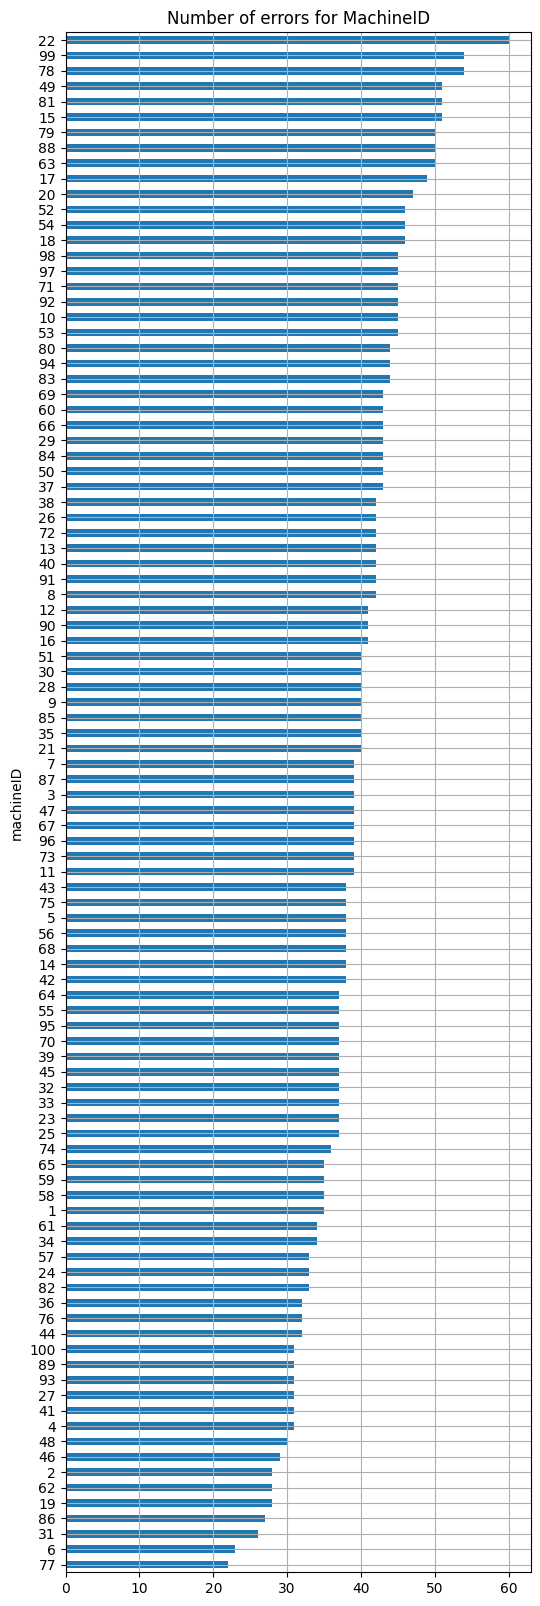

In [37]:

errors["machineID"].value_counts(
                normalize=False, dropna=False).sort_values().plot(
                kind='barh', figsize=(6, 20), grid=True,
                title="Number of errors for MachineID")

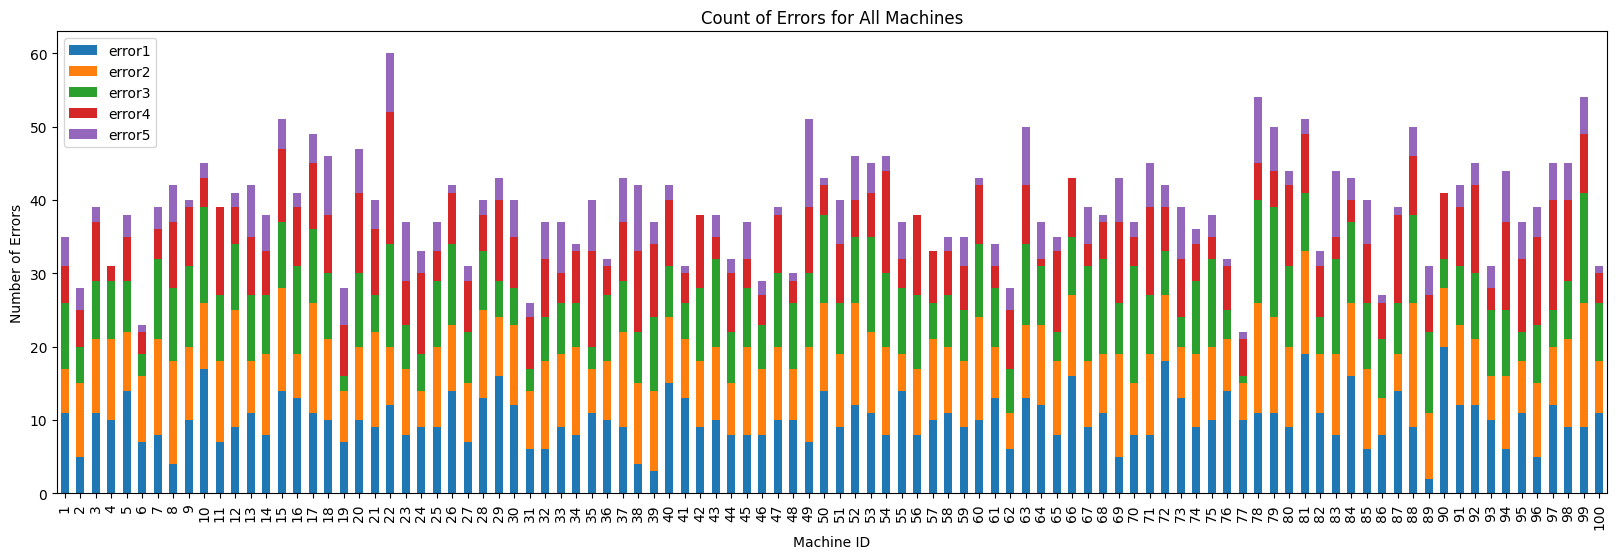

In [38]:
error_cnt = errors.groupby(["machineID", "errorID"]).size().reset_index()
error_cnt.columns = ["machineID", "errorID", "error_val"]
error_cnt_pivot = pd.pivot(error_cnt, index="machineID", columns="errorID", values="error_val").rename_axis(None, axis=1)
error_cnt_pivot.plot.bar(stacked=True, figsize=(20, 6), title="Count of Errors for All Machines")
plt.xlabel("Machine ID")
plt.ylabel("Number of Errors");

 ## Maintainence 

In [39]:
maint['comp'] = maint['comp'].astype('object')

print(f"Total number of maintenance records: {len(maint.index)}")
maint.head()

Total number of maintenance records: 3286


,datetime,machineID,comp
0,2014-06-01 06:00:00,1,comp2
1,2014-07-16 06:00:00,1,comp4
2,2014-07-31 06:00:00,1,comp3
3,2014-12-13 06:00:00,1,comp1
4,2015-01-05 06:00:00,1,comp4


In [40]:
fig = px.bar(x=maint['comp'].values,
             title='Count of Comp', template='none', color=maint['comp'].values) #
fig.update_layout(xaxis_title='Comp Type', yaxis_title='Count',xaxis={'categoryorder':'total descending'})
fig.show()

Gtk-Message: 11:32:25.188: Not loading module "atk-bridge": The functionality is provided by GTK natively. Please try to not load it.
Gtk-Message: 11:32:25.233: Failed to load module "canberra-gtk-module"
Gtk-Message: 11:32:25.234: Failed to load module "canberra-gtk-module"


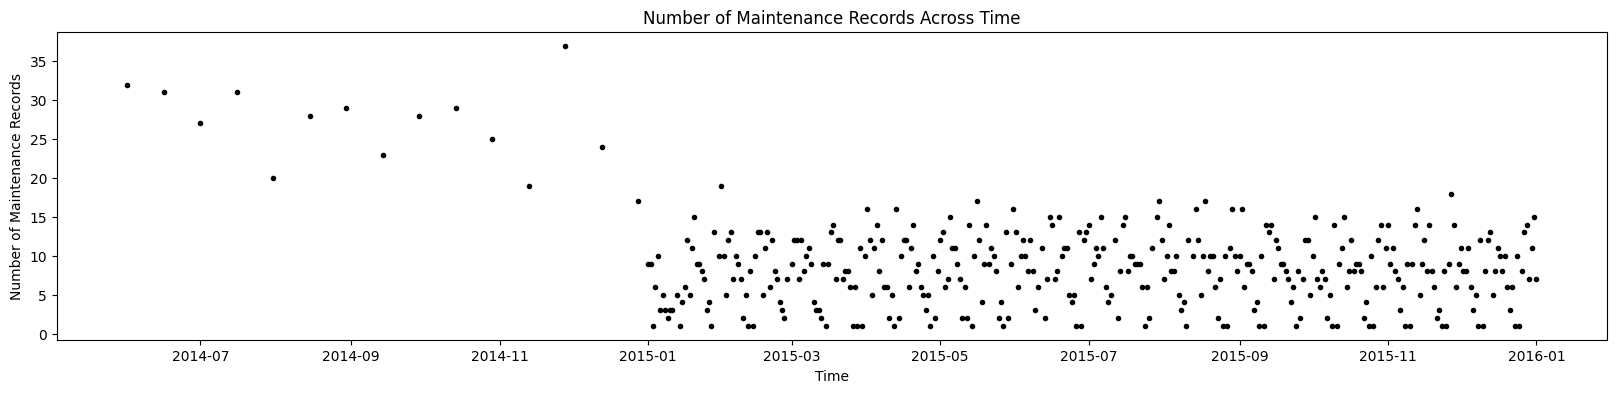

In [41]:
maint['datetime'] = pd.to_datetime(maint['datetime'])  # Ensure datetime type

maint['datetime'].dt.date.value_counts().sort_index().plot(
    style="k.",
    figsize=(20, 4),
    title="Number of Maintenance Records Across Time"
)

plt.ylabel("Number of Maintenance Records")
plt.xlabel("Time")
plt.show()


This indicates that data is sparse in 2014 when compared to the number of maintenance records in 2015.



# failures

In [42]:
failures['failure'] = failures['failure'].astype('object')

print(f"Total number of failures: {len(failures.index)}")
failures.head()

Total number of failures: 761


,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2
3,2015-06-19 06:00:00,1,comp4
4,2015-09-02 06:00:00,1,comp4


<Axes: xlabel='failure'>

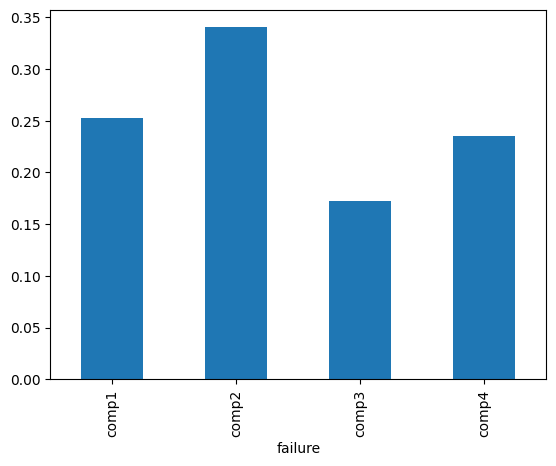

In [43]:
# by component

(failures.failure.value_counts() / failures.shape[0]).sort_index().plot(kind='bar')

<Axes: xlabel='cumulative_failures'>

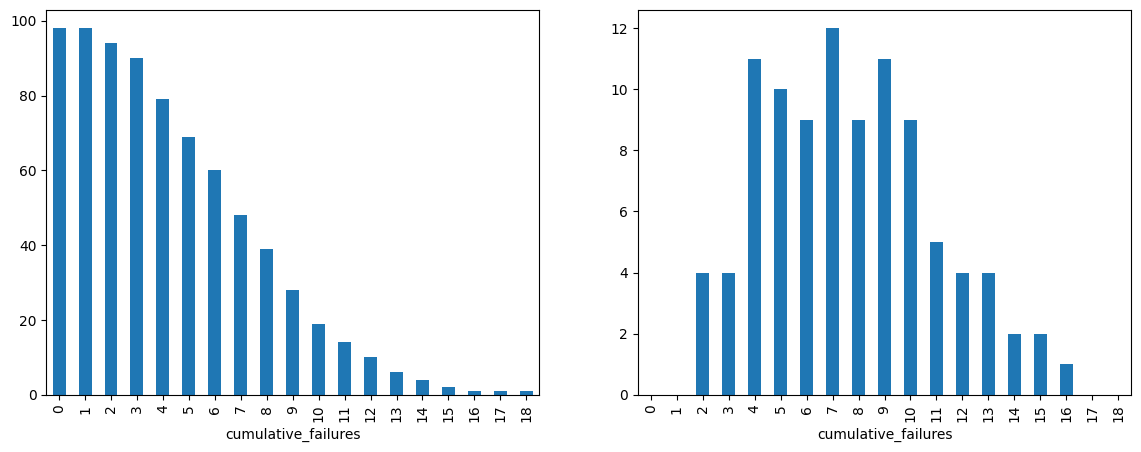

In [44]:
# cumulative failures

failures['cumulative_failures'] = failures.groupby('machineID').datetime.cumcount()

fig, ax = plt.subplots(1,2, figsize=(14, 5))
failures.cumulative_failures.value_counts().plot(kind='bar', ax=ax[0])
failures.cumulative_failures.value_counts().diff().abs().plot(kind='bar', ax=ax[1])

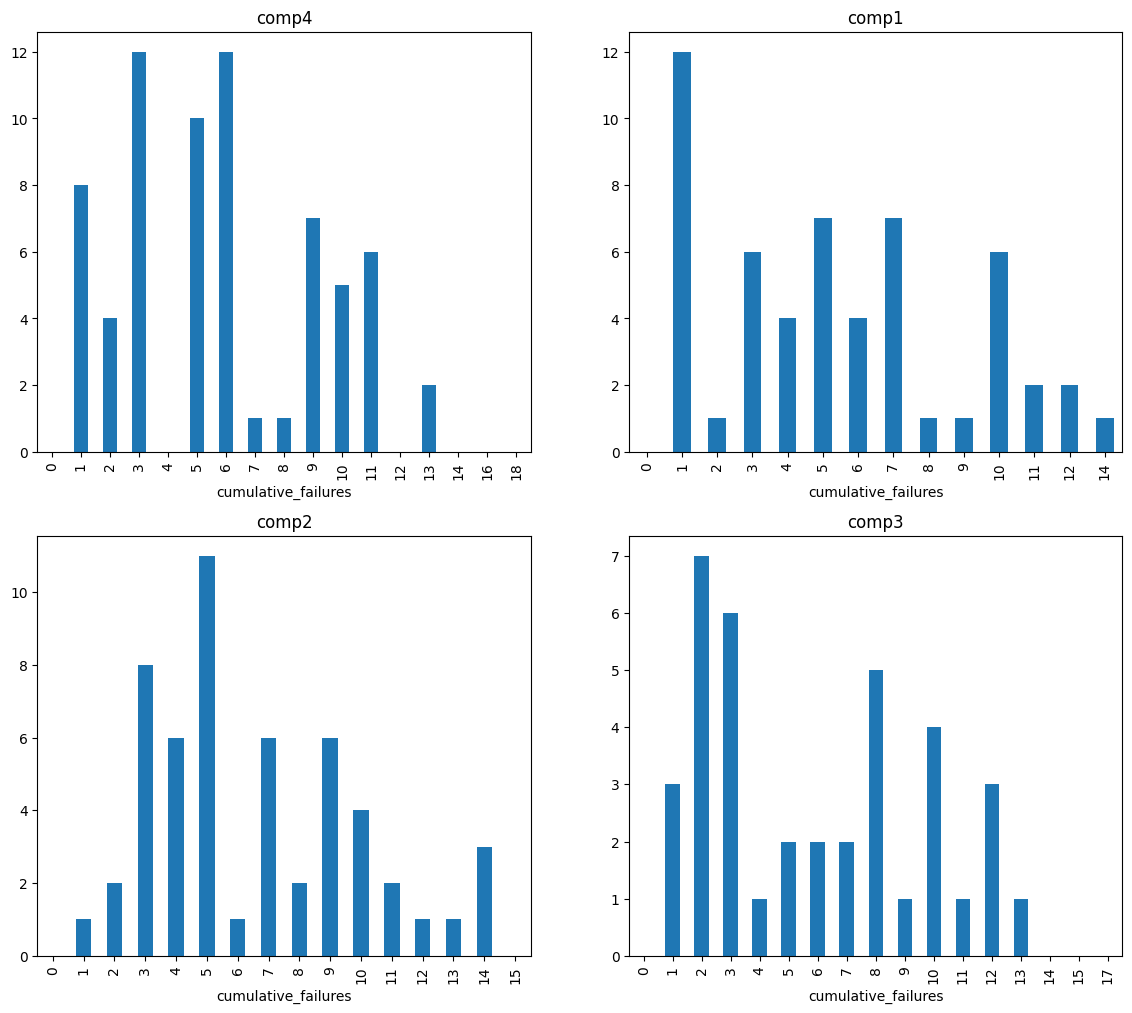

In [45]:
failures['comp_cumulative_failures'] = failures.groupby(['machineID','failure']).cumcount()

fig, ax = plt.subplots(2,2, figsize=(14, 12))
for i, f in enumerate(failures.failure.unique()):
    failures[failures.failure == f].cumulative_failures.value_counts().sort_index().diff().abs().plot(kind='bar', ax=ax[i//2, i%2])
    ax[i//2, i%2].set_title(f)

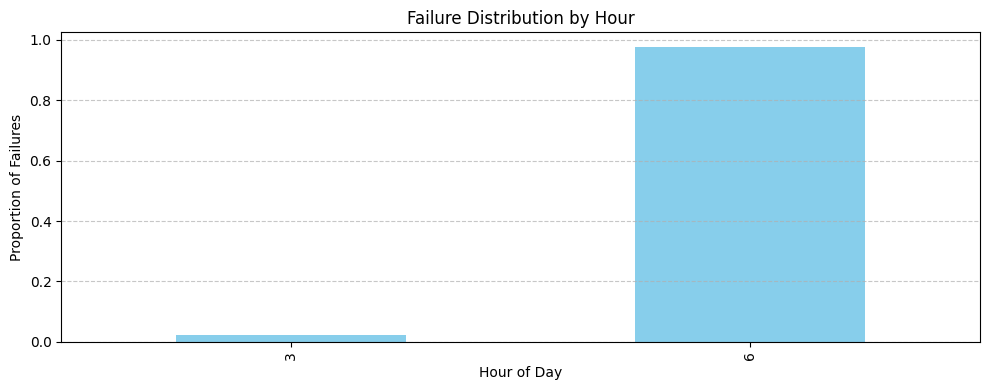

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert 'datetime' column to datetime type (if not already)
failures['datetime'] = pd.to_datetime(failures['datetime'], errors='coerce')

# Drop rows where datetime conversion failed (optional safety step)
failures = failures.dropna(subset=['datetime'])

# Plot proportion of failures by hour of day
(failures['datetime'].dt.hour.value_counts(normalize=True)
 .sort_index()
 .plot(kind='bar', figsize=(10, 4), color='skyblue', title='Failure Distribution by Hour'))

plt.xlabel('Hour of Day')
plt.ylabel('Proportion of Failures')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [47]:
fig = px.bar(x=failures['failure'].values, title='Count of Failures', template='none', color=failures['failure'].values)
fig.update_layout(xaxis_title='Failure Type', yaxis_title='Count',xaxis={'categoryorder':'total descending'})
fig.show()

Gtk-Message: 11:32:42.862: Not loading module "atk-bridge": The functionality is provided by GTK natively. Please try to not load it.
Gtk-Message: 11:32:42.897: Failed to load module "canberra-gtk-module"
Gtk-Message: 11:32:42.898: Failed to load module "canberra-gtk-module"


<Axes: xlabel='dow'>

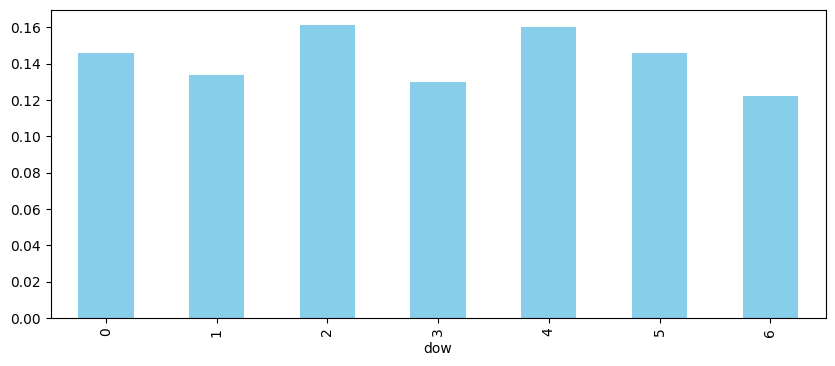

In [48]:
# by day of the week
failures['dow'] = failures['datetime'].dt.dayofweek
(failures.dow.value_counts() / failures.shape[0]).sort_index().plot(kind='bar',figsize=(10, 4), color='skyblue')

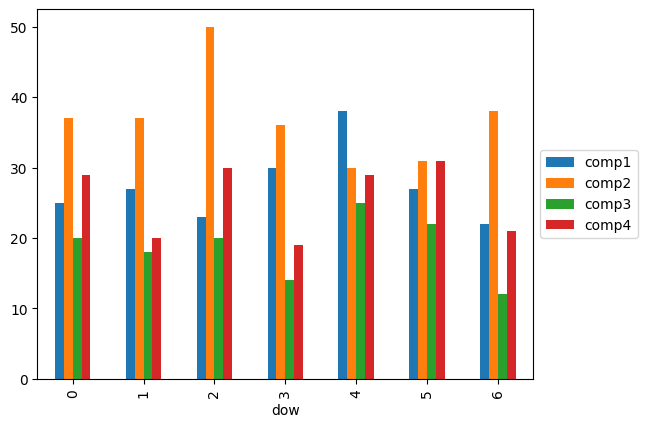

In [49]:
# by dow and component
failures.groupby(['dow', 'failure']).size().unstack().plot(kind='bar', stacked=False)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

## Machine 

In [50]:
machines['model'] = machines['model'].astype('object')

print(f"Total number of machines: {len(machines.index)}")
machines.head()

Total number of machines: 100


,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8
3,4,model3,7
4,5,model3,2


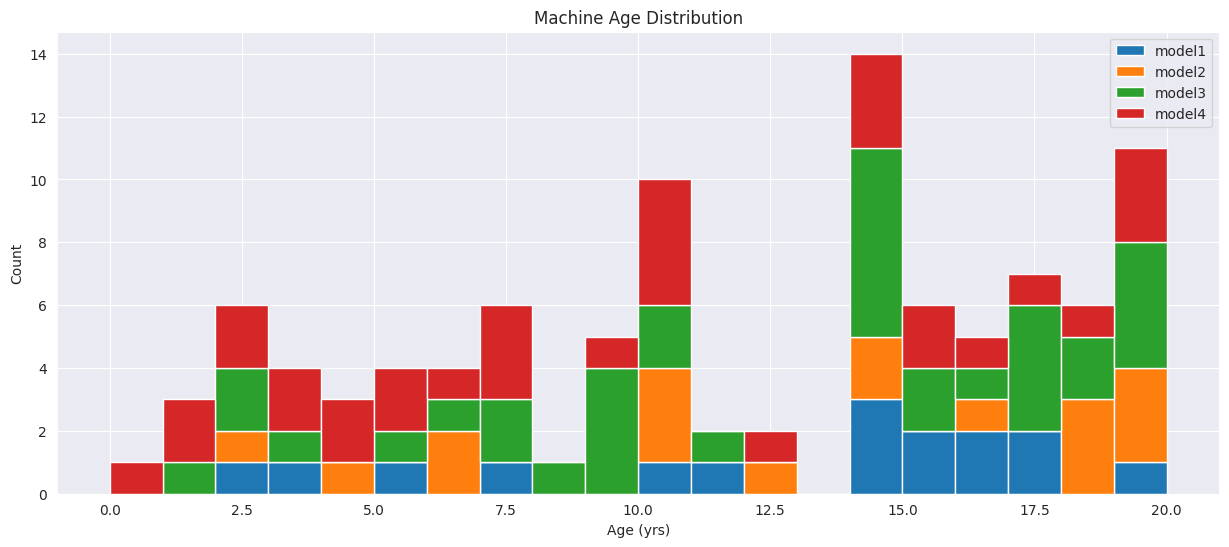

In [51]:
sns.set_style("darkgrid")
plt.figure(figsize=(15, 6))
_, bins, _ = plt.hist([machines.loc[machines['model'] == 'model1', 'age'],
                       machines.loc[machines['model'] == 'model2', 'age'],
                       machines.loc[machines['model'] == 'model3', 'age'],
                       machines.loc[machines['model'] == 'model4', 'age']],
                       20, stacked=True, label=['model1', 'model2', 'model3', 'model4'])
plt.xlabel('Age (yrs)')
plt.ylabel('Count')
plt.title('Machine Age Distribution')
plt.legend()
plt.show()

In [52]:
df = failures.merge(machines, on='machineID', how='left')
df.head()

,datetime,machineID,failure,cumulative_failures,comp_cumulative_failures,dow,model,age
0,2015-01-05 06:00:00,1,comp4,0,0,0,model3,18
1,2015-03-06 06:00:00,1,comp1,1,0,4,model3,18
2,2015-04-20 06:00:00,1,comp2,2,0,0,model3,18
3,2015-06-19 06:00:00,1,comp4,3,1,4,model3,18
4,2015-09-02 06:00:00,1,comp4,4,2,2,model3,18


In [53]:
model_dist = (machines.model.value_counts() / machines.shape[0]).reset_index()
model_dist['subset'] = 'all'
age_dist = (machines.age.value_counts() / machines.shape[0]).reset_index()
age_dist['subset'] = 'all'

def machine_distribtutions_comp(data):
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    
    i = 0
    for col, dist in zip(['model', 'age'], [model_dist, age_dist]):
        failure_dist = (data[col].value_counts() / data.shape[0]).reset_index()
        failure_dist['subset'] = 'failure'
        sns.barplot(x=col, y='count', data=pd.concat([dist, failure_dist]), hue='subset', ax=ax[i])
        i += 1
    
    return ax

array([<Axes: xlabel='model', ylabel='count'>,
       <Axes: xlabel='age', ylabel='count'>], dtype=object)

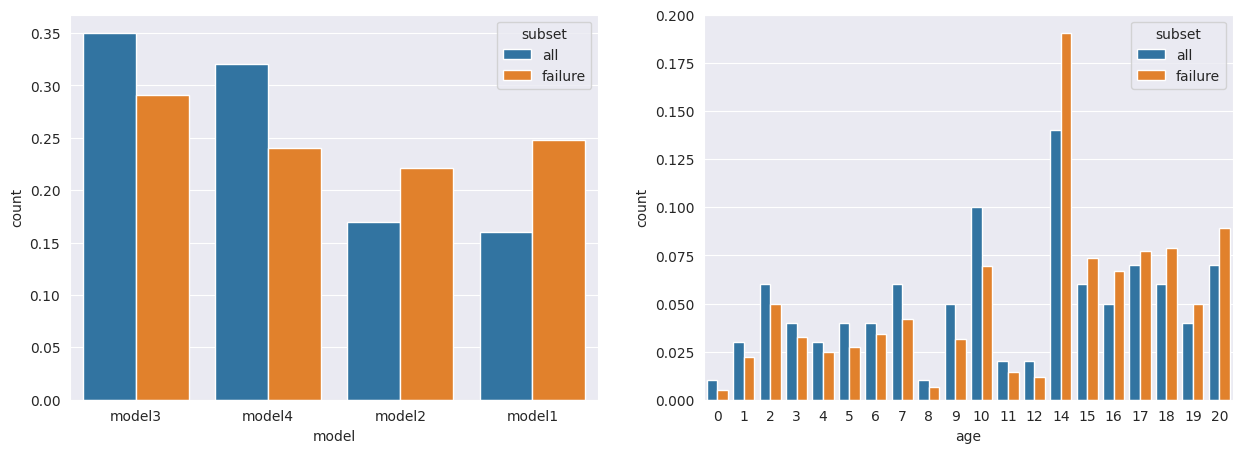

In [54]:
# all failures
machine_distribtutions_comp(df)

array([<Axes: xlabel='model', ylabel='count'>,
       <Axes: xlabel='age', ylabel='count'>], dtype=object)

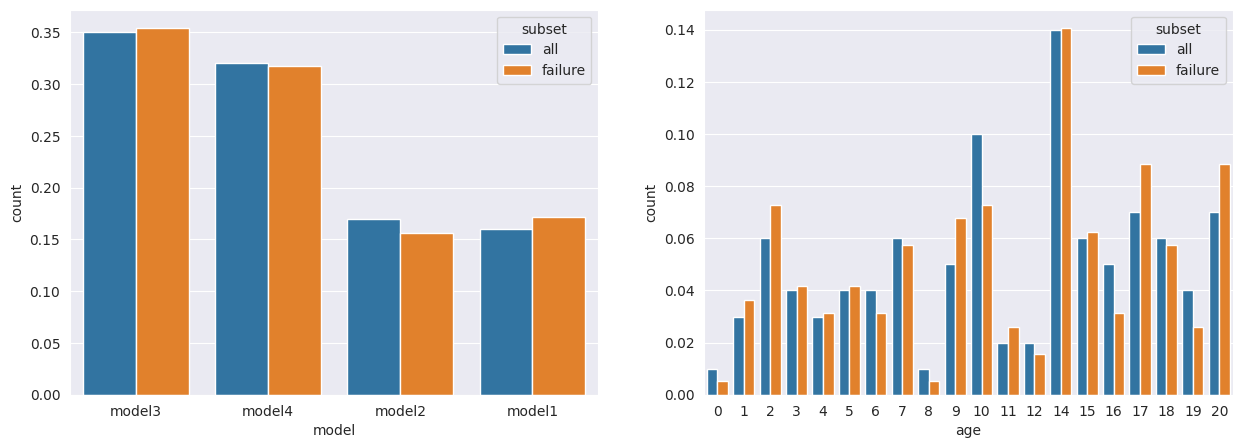

In [55]:
machine_distribtutions_comp(df[df.failure == 'comp1'])

array([<Axes: xlabel='model', ylabel='count'>,
       <Axes: xlabel='age', ylabel='count'>], dtype=object)

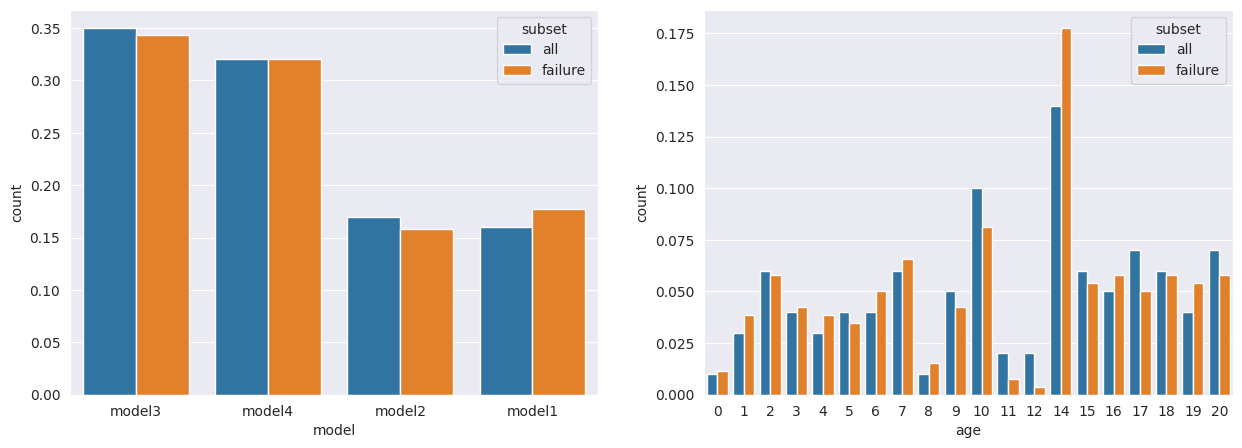

In [56]:
# failure comp2
machine_distribtutions_comp(df[df.failure == 'comp2'])

array([<Axes: xlabel='model', ylabel='count'>,
       <Axes: xlabel='age', ylabel='count'>], dtype=object)

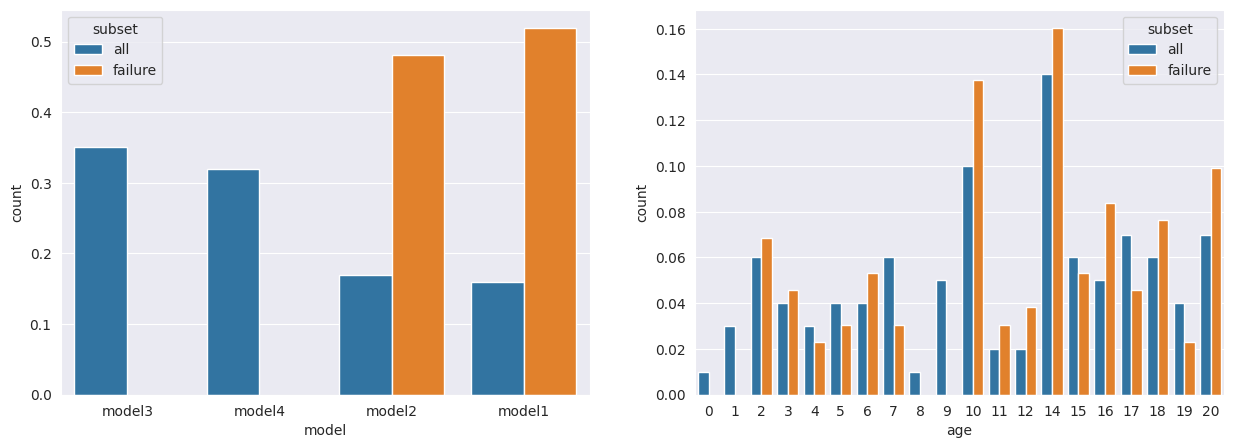

In [57]:
# failure comp3
machine_distribtutions_comp(df[df.failure == 'comp3'])

array([<Axes: xlabel='model', ylabel='count'>,
       <Axes: xlabel='age', ylabel='count'>], dtype=object)

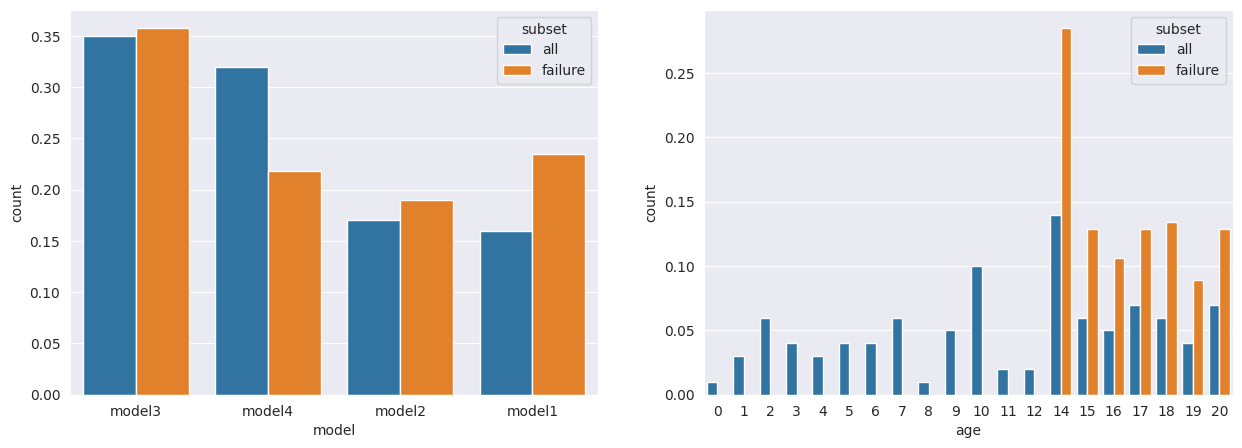

In [58]:
# failure comp4
machine_distribtutions_comp(df[df.failure == 'comp4'])

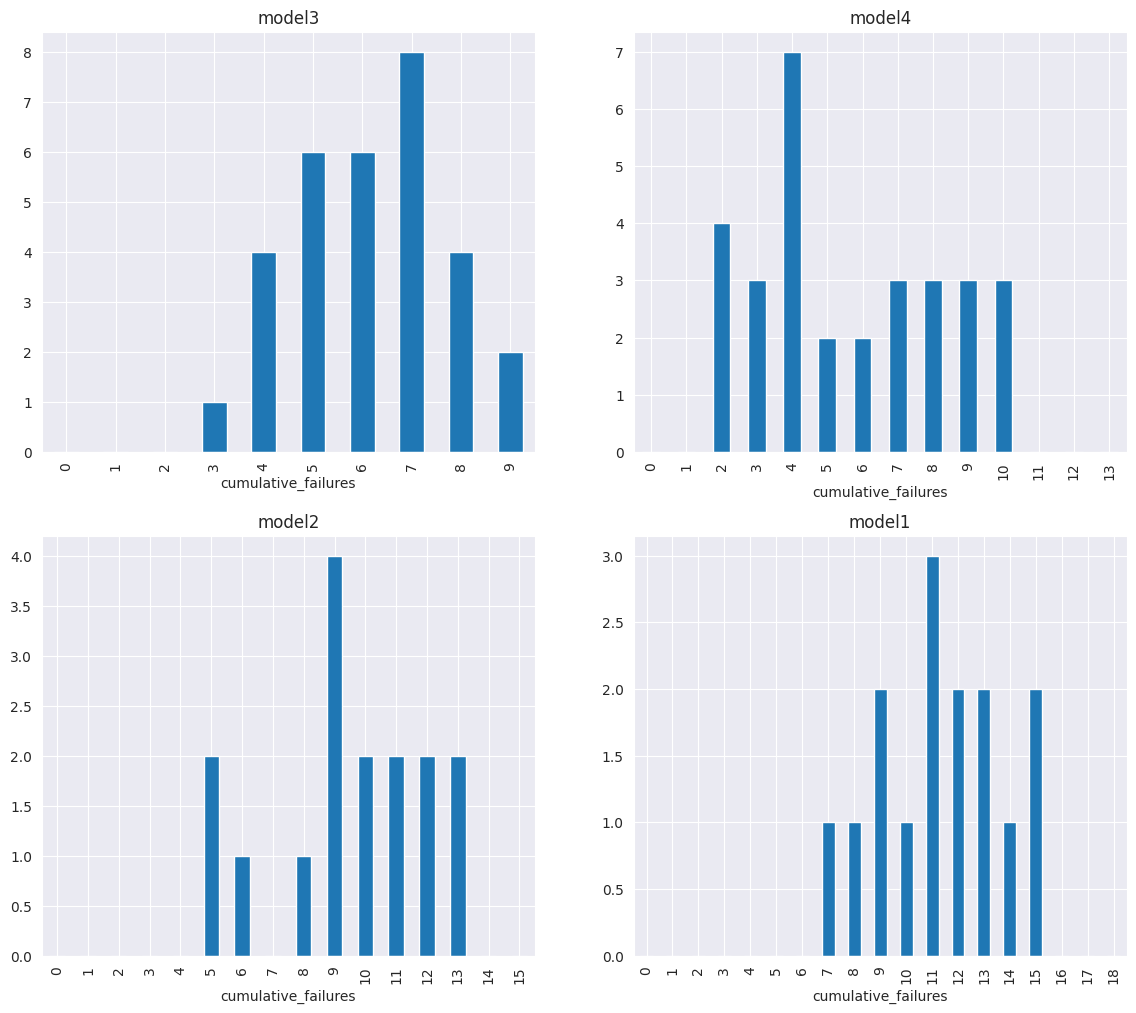

In [59]:
fig, ax = plt.subplots(2,2, figsize=(14, 12))
for i, model in enumerate(df.model.unique()):
    df[df.model == model].cumulative_failures.value_counts().diff().abs().plot(kind='bar', ax=ax[i//2, i%2])
    ax[i//2, i%2].set_title(model)

# Dataset Construction


In [60]:
# Step 1: Ensure 'datetime' is in datetime format
telemetry['datetime'] = pd.to_datetime(telemetry['datetime'], errors='coerce')

# Step 2: Drop rows with invalid datetime (if any)
telemetry = telemetry.dropna(subset=['datetime'])

# Step 3: Feature Engineering - Shift and Rolling Means
cols = ['volt', 'rotate', 'pressure', 'vibration']

# 24 hours before (lag)
telemetry[cols] = telemetry.groupby('machineID')[cols].shift(24)

# Last day (24H) mean
ld_cols = [c + '_ld_mean' for c in cols]
telemetry[ld_cols] = telemetry.groupby('machineID').rolling(24)[cols].mean().values

# Last 3 days (72H) mean
l3d_cols = [c + '_l3d_mean' for c in cols]
telemetry[l3d_cols] = telemetry.groupby('machineID').rolling(24 * 3)[cols].mean().values

# Last week (168H) mean
lw_cols = [c + '_lw_mean' for c in cols]
telemetry[lw_cols] = telemetry.groupby('machineID').rolling(24 * 7)[cols].mean().values

# Last 2 weeks (336H) mean
l2w_cols = [c + '_l2w_mean' for c in cols]
telemetry[l2w_cols] = telemetry.groupby('machineID').rolling(24 * 7 * 2)[cols].mean().values

# Step 4: Filter for 6 AM readings only (as most failures happen at 6 AM)
telemetry = telemetry[telemetry['datetime'].dt.hour == 6].copy(deep=True)

# Step 5: Convert datetime to date only
telemetry['datetime'] = telemetry['datetime'].dt.date


In [61]:
# changes to failures
failures['datetime'] = failures.datetime.dt.date

In [62]:
# merge in one df

df = telemetry.merge(pd.get_dummies(failures, columns=['failure'], dtype=float), how = 'left')
df[df.columns[-4:]] = df[df.columns[-4:]].fillna(0)

In [63]:
# add cumulative failures

df['failure'] = df.iloc[:,-4:].sum(axis=1)
for col in df.columns[-5:]:
    df[f'cm_{col}'] = df.groupby('machineID')[col].cumsum().shift(1).fillna(0)
    
df.head(15)

,datetime,machineID,volt,rotate,pressure,vibration,volt_ld_mean,rotate_ld_mean,pressure_ld_mean,vibration_ld_mean,...,failure_comp1,failure_comp2,failure_comp3,failure_comp4,failure,cm_failure_comp1,cm_failure_comp2,cm_failure_comp3,cm_failure_comp4,cm_failure
0,2015-01-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2015-01-02,1,176.217853,418.504078,113.077935,45.087686,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2015-01-03,1,197.363125,446.943947,114.342061,29.527665,170.614862,446.364859,96.849785,39.736826,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2015-01-04,1,177.594089,459.956670,96.651624,52.997327,169.533156,454.785072,100.050567,39.449734,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2015-01-05,1,165.010140,448.468838,97.709630,48.238941,172.042428,450.418764,100.284484,52.153213,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
5,2015-01-06,1,179.303153,499.777962,111.833028,52.383097,171.929104,443.448775,98.675590,51.780445,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
6,2015-01-07,1,183.427580,437.628228,94.006105,37.985005,171.565333,465.770206,103.709367,39.399404,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
7,2015-01-08,1,180.783331,421.676066,83.673324,39.450313,171.625196,441.774893,101.000854,41.917576,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
8,2015-01-09,1,175.774030,410.689641,111.705103,36.861498,171.387727,454.941834,98.263990,41.534184,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
9,2015-01-10,1,143.506562,438.705929,94.273119,47.929077,172.048322,448.430603,102.418424,39.297874,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [64]:
# days since last failure

for col in df.columns[-5:]:
    try:
        n_comp = int(col[-1])
    except:
        n_comp = ''
    
    df[f'days_since_lf{n_comp}'] = df.groupby(['machineID', col]).cumcount() + 1
    df.loc[df[col] == 0, f'days_since_lf{n_comp}'] = 0

In [65]:
# dummy 15 days

df['d15_lf'] = df.days_since_lf.apply(lambda x: 1 if x > 0 and x % 15 == 0 else 0)

In [66]:
# day of the week 

dow_dummies = pd.get_dummies(pd.to_datetime(df.datetime).dt.day_of_week, 'dow', dtype=float)
df = pd.concat([df, dow_dummies], axis=1)

In [67]:
# add machine data 

df = df.merge(pd.get_dummies(machines, columns=['model'],  dtype=float))
df.head()

,datetime,machineID,volt,rotate,pressure,vibration,volt_ld_mean,rotate_ld_mean,pressure_ld_mean,vibration_ld_mean,...,dow_2,dow_3,dow_4,dow_5,dow_6,age,model_model1,model_model2,model_model3,model_model4
0,2015-01-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,0.0,18,0.0,0.0,1.0,0.0
1,2015-01-02,1,176.217853,418.504078,113.077935,45.087686,NaN,NaN,NaN,NaN,...,0.0,0.0,1.0,0.0,0.0,18,0.0,0.0,1.0,0.0
2,2015-01-03,1,197.363125,446.943947,114.342061,29.527665,170.614862,446.364859,96.849785,39.736826,...,0.0,0.0,0.0,1.0,0.0,18,0.0,0.0,1.0,0.0
3,2015-01-04,1,177.594089,459.956670,96.651624,52.997327,169.533156,454.785072,100.050567,39.449734,...,0.0,0.0,0.0,0.0,1.0,18,0.0,0.0,1.0,0.0
4,2015-01-05,1,165.010140,448.468838,97.709630,48.238941,172.042428,450.418764,100.284484,52.153213,...,0.0,0.0,0.0,0.0,0.0,18,0.0,0.0,1.0,0.0


In [68]:
# changes to maintenance data

maint['datetime'] = maint.datetime.dt.date
maint = maint.merge(failures, left_on=['datetime', 'machineID', 'comp'], right_on=['datetime', 'machineID', 'failure'], how='left')
maint = maint[maint.failure.isnull()].copy(deep=True) # keep only proactive maintenance
maint = pd.get_dummies(maint, columns=['comp'], dtype=float)
maint = maint.drop('failure', axis=1)

In [ ]:
print(maint.columns.tolist())


['datetime', 'machineID', 'cumulative_failures', 'comp_cumulative_failures', 'dow', 'comp_comp1', 'comp_comp2', 'comp_comp3', 'comp_comp4']


In [ ]:
# Step 1: Ensure 'datetime' is in datetime format
maint['datetime'] = pd.to_datetime(maint['datetime'], errors='coerce')
failures['datetime'] = pd.to_datetime(failures['datetime'], errors='coerce')

# Step 2: Extract only the date part
maint['datetime'] = maint['datetime'].dt.date
failures['datetime'] = failures['datetime'].dt.date

# Step 3: Merge maintenance with failures to identify proactive maintenance (i.e., no failure matched)
maint = maint.merge(
    failures,
    left_on=['datetime', 'machineID', 'comp'],
    right_on=['datetime', 'machineID', 'failure'],
    how='left'
)

# Step 4: Keep only proactive maintenance rows (i.e., those with no failure recorded at that time)
maint = maint[maint['failure'].isnull()].copy(deep=True)

# Step 5: One-hot encode component names
maint = pd.get_dummies(maint, columns=['comp'], dtype=float)

# Step 6: Drop the 'failure' column from the merge
maint = maint.drop('failure', axis=1)


In [ ]:
# merge maint to df

df = df.merge(maint, how = 'left')
df[maint.columns[-4:]] = df[maint.columns[-4:]].fillna(0).shift(1)

In [ ]:
# remoce the model_ and comp_ from dummies

rename_cols = {col: col.split('_')[-1] for col in df.columns[-8:]}
df = df.rename(columns=rename_cols)

In [ ]:
# cumulative proactive maintenances

df['maint'] = df.iloc[:,-4:].sum(axis=1)
for col in df.columns[-5:]:
    df[f'cm_{col}'] = df.groupby('machineID')[col].cumsum()

In [ ]:
df.head()

In [ ]:
# days since last maintenance

for col in df.columns[-5:]:
    try:
        n_comp = int(col[-1])
    except:
        n_comp = ''
    
    df[f'days_since_lm{n_comp}'] = df.groupby(['machineID', col]).cumcount()
    df.loc[df[col] == 0, f'days_since_lm{n_comp}'] = 0

In [ ]:

# last week maintenance
m_cols = ['comp1', 'comp2', 'comp3', 'comp4', 'maint']
lw_cols = [f'lw_{c}' for c in m_cols]
df[lw_cols] = df.groupby('machineID')[m_cols].rolling(7).sum().values

# last 2 weeks maintenance
l2w_cols = [f'l2w_{c}' for c in m_cols]
df[l2w_cols] = df.groupby('machineID')[m_cols].rolling(7*2).sum().values

In [ ]:
# changes to errors data

# Convert 'datetime' to datetime format first
errors['datetime'] = pd.to_datetime(errors['datetime'], errors='coerce')

# Shift datetime 6 hours back to match telemetry, failures, and maintenance
errors['datetime'] = errors['datetime'] - pd.Timedelta(hours=6)

# Extract just the date part
errors['datetime'] = errors['datetime'].dt.date

# One-hot encode 'errorID' column
errors = pd.get_dummies(errors, columns=['errorID'], dtype=float)

# Rename the columns (last 5 columns) for better clarity
rename_cols = {col: col.split('_')[-1] for col in errors.columns[-5:]}
errors = errors.rename(columns=rename_cols)

# Show the first few rows of the data
errors.head()


In [ ]:
errors = errors.groupby(['datetime', 'machineID']).sum().reset_index().sort_values(['machineID', 'datetime'])
errors.head()

In [ ]:
# merge errors

df = df.merge(errors, how='left')
df[errors.columns[-5:]] = df[errors.columns[-5:]].fillna(0).shift(2)
df.head()

In [ ]:
# cumulative errors

df['errors'] = df.iloc[:,-5:].sum(axis=1)
for col in df.columns[-5:]:
    df[f'cm_{col}'] = df.groupby('machineID')[col].cumsum()
    
df.head()

In [ ]:
# last week errors
e_cols = ['error1', 'error2', 'error3', 'error4', 'error5', 'errors']
lw_cols = [f'lw_{c}' for c in e_cols]
df[lw_cols] = df.groupby('machineID')[e_cols].rolling(7).sum().values

# last 2 weeks errors
l2w_cols = [f'l2w_{c}' for c in e_cols]
df[l2w_cols] = df.groupby('machineID')[e_cols].rolling(7*2).sum().values

In [ ]:
model_df = df.dropna().copy(deep=True).iloc[:, 2:]
model_df.columns

In [ ]:
# standardize data

std_cols = list()
for col in model_df.columns:
    if model_df[col].unique().shape[0] > 2:
        std_cols.append(col)

model_df[std_cols] = StandardScaler().fit_transform(model_df[std_cols])

In [ ]:
model_df = model_df.drop('failure', axis=1)

In [ ]:
y_cols = ['failure_comp1', 'failure_comp2', 'failure_comp3', 'failure_comp4']
x_cols = [col for col in model_df.columns if col not in y_cols]

In [ ]:
X = model_df[x_cols].values
Y = model_df[y_cols].values

# Model